In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.gridspec import GridSpec

from fiat_toolbox.well_being import CommunityUnit, WellBeingConfig, CapitalStock, IncomeConfig, SimulationConfig, Liquidity, LossType

In [2]:
housing_assets = CapitalStock(v=0.7, k=120000)
rental_assets = CapitalStock(v=0.7, k=50000, recovery_time=5)

public_assets = CapitalStock(v=0.4, k=5e-2*5000000, recovery_time=5)
private_assets = CapitalStock(v=0.4, k=1e-2*5000000, recovery_time=4)

income_config = IncomeConfig(i_0=48000, i_avg=48000, pi=0.15, i_div=5000)
sim_config = SimulationConfig(eta=1.5, rho=0.06, t_max=10, dt=1/52, currency="$", c_min=0.0, recovery_per=95.0)
liq = Liquidity(savings=0)

config = WellBeingConfig(
    owner_housing=housing_assets,
    # labour_assets={"Public":public_assets, "Private":private_assets},
    # rental_housing=rental_assets,
    income=income_config,
    simulation=sim_config,
    liquidity=liq
    
)

In [3]:
# Create a WellBeing object and optimize the lambda value
household = CommunityUnit(config=config)
household

CommunityUnit(
  owner_housing = k=120000.0 v=0.7 recovery_time=None recovery_rate=None,
  rental_housing = None,
  labour_assets = None,
  income = i_0=48000.0 i_avg=48000.0 pi=0.15 i_div=5000.0,
  liquidity = savings=0.0 insurance=0.0 support=0.0,
  simulation = eta=1.5 rho=0.06 t_max=10.0 dt=0.019230769230769232 currency='$' c_min=0.0 recovery_per=95.0
)

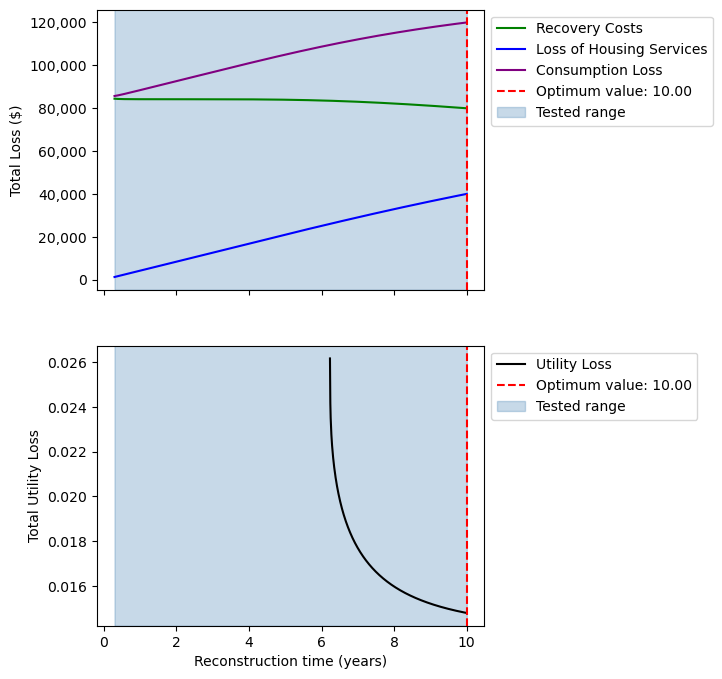

In [4]:
household.opt_lambda(method="trapezoid", eps_rel=0.)
household.plot_opt_lambda(x_type="time");

In [5]:
household.get_losses("trapezoid")

Recovery Costs               79800.219863
Loss of Housing Services     39956.951711
Consumption Loss            119757.171574
Utility Loss                     0.014780
Wellbeing Loss              136465.059121
Asset Loss                   84000.000000
Equity Weighted Loss         72398.128157
dtype: float64

In [6]:
print(f"Recovery Time: {household.recovery_time:.2f} years")
# TODO CHEKC WHY THIS IS WRONG!

Recovery Time: 7.77 years


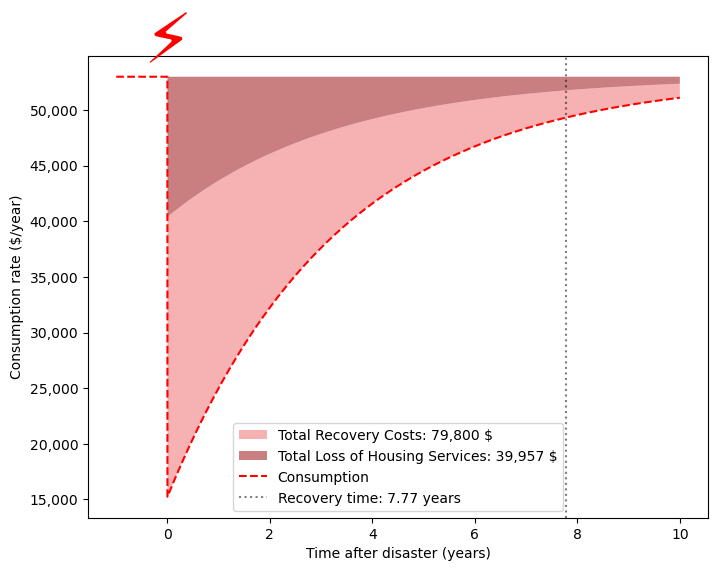

In [7]:
household.plot_consumption()